In [42]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sb
import SensoriMotorPrediction.globals as gl
import PcmPy as pcm
from SensoriMotorPrediction.vis import plot_rdm
import nibabel as nb

# Average betas (example participant)

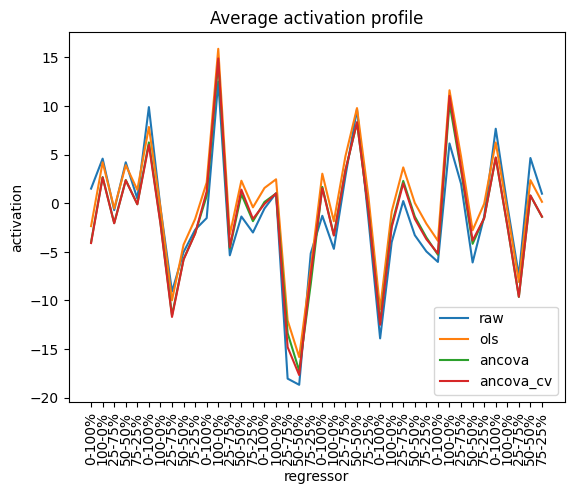

In [48]:
glm = 16
sn = 102
experiment = 'smp2'

B = nb.load(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'beta.dscalar.nii'))

reginfo = pd.read_csv(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'subj{sn}_reginfo.tsv'), sep='\t')
reginfo.name = reginfo.name.str.replace(' ', '')
reginfo['BN'] = reginfo['run']
tmp = reginfo['name'].str.split(',', expand=True)
reginfo['cue'] = tmp[0]

data = B.get_fdata()[reginfo.name.isin(gl.cues)]

B_ols = nb.load(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'beta.ols.dscalar.nii'))
data_ols = B_ols.get_fdata()

B_ancova = nb.load(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'beta.ancova.dscalar.nii'))
data_ancova = B_ancova.get_fdata()

B_ancova_cv = nb.load(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'beta.ancova_cv.dscalar.nii'))
data_ancova_cv = B_ancova_cv.get_fdata()

plt.plot(np.nanmean(data,axis=1), label='raw')
plt.plot(np.nanmean(data_ols, axis=1), label='ols')
plt.plot(np.nanmean(data_ancova, axis=1), label='ancova')
plt.plot(np.nanmean(data_ancova_cv, axis=1), label='ancova_cv')
plt.legend()
plt.ylabel('activation')
plt.xlabel('regressor')
labels = reginfo.cue[reginfo.name.isin(gl.cues)]
plt.xticks(range(len(labels)), labels, rotation=90)
plt.title('Average activation profile')
plt.show()

# Raw disimilarities

Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=2.164199146488875, pval=0.024825486982829666
PMd: tval=4.001272903935592, pval=0.0007542298155766069
PMv: tval=3.554106177981126, pval=0.0017642778458149444
M1: tval=4.198985530252177, pval=0.0005207634764951628
S1: tval=4.679053917584281, pval=0.00021561721380236707
SPLa: tval=6.848949532017808, pval=5.8608795789972164e-06
SPLp: tval=4.746287379067999, pval=0.00019098789628770174


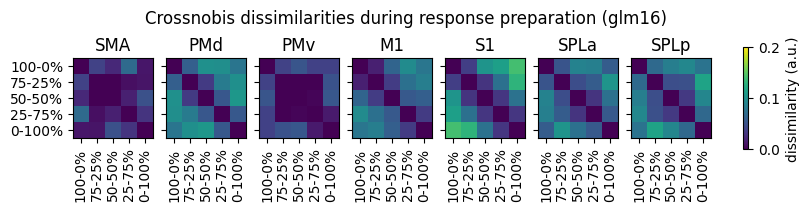

In [13]:
H = 'L'
rois = gl.rois['ROI']
glm = 16
vmin, vmax = 0, .2
fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    plot_rdm(fig, axs, r, D, ['100-0%', '75-25%', '50-50%', '25-75%', '0-100%'], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle(f'Crossnobis dissimilarities during response preparation (glm{glm})')
fig.savefig(os.path.join('figures', f'crossnobis.plan.glm{glm}.pdf'))
plt.show()

# Pre-activation regressed out

### Using OLS

Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=0.7749645452431012, pval=0.2261134985983358
PMd: tval=2.815786269877652, pval=0.007291127927561343
PMv: tval=0.937092652527438, pval=0.18289729322566994
M1: tval=2.744420404964382, pval=0.00835753917781262
S1: tval=3.0217402793065973, pval=0.00490980070965781
SPLa: tval=4.354556713411924, pval=0.0003902003027380466
SPLp: tval=3.1554478186313455, pval=0.003795797402716654


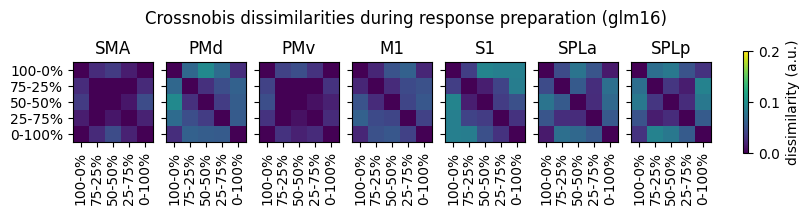

In [14]:
fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ols.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    plot_rdm(fig, axs, r, D, ['100-0%', '75-25%', '50-50%', '25-75%', '0-100%'], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle(f'Crossnobis dissimilarities during response preparation (glm{glm})')
#fig.savefig(os.path.join('figures', f'crossnobis.plan.glm{glm}.pdf'))
plt.show()

### Using ANCOVA

Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=3.9540548797352812, pval=0.0008244369850083878
PMd: tval=4.082305344472668, pval=0.000647701560927464
PMv: tval=3.930990246832395, pval=0.0008611317379264368
M1: tval=5.506908843900673, pval=5.0478003891249505e-05
S1: tval=5.976297682553632, pval=2.310590659701574e-05
SPLa: tval=4.697325972431211, pval=0.00020861369031365042
SPLp: tval=3.9879109355730464, pval=0.000773451980255533


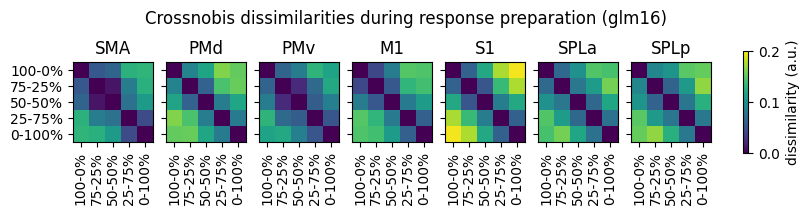

In [15]:
fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ancova.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    plot_rdm(fig, axs, r, D, ['100-0%', '75-25%', '50-50%', '25-75%', '0-100%'], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle(f'Crossnobis dissimilarities during response preparation (glm{glm})')
#fig.savefig(os.path.join('figures', f'crossnobis.plan.glm{glm}.pdf'))
plt.show()

### Using cross-validated ANCOVA

Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=3.252798181832593, pval=0.0031471215889798056
PMd: tval=3.580514582357903, pval=0.0016773039864534194
PMv: tval=3.1872559459862146, pval=0.0035703254485162416
M1: tval=5.003454443224205, pval=0.00012073793932371692
S1: tval=5.437671201050091, pval=5.679256670095395e-05
SPLa: tval=4.1356558087206245, pval=0.000586118776582263
SPLp: tval=3.595831656250486, pval=0.0016288643596635746


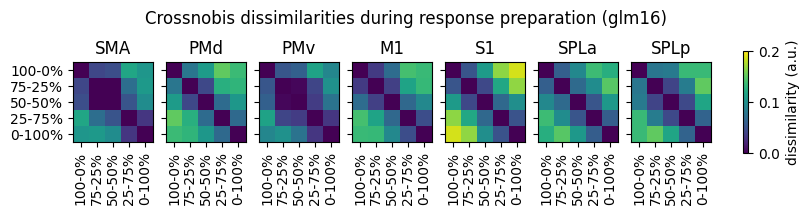

In [16]:
fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ancova_cv.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    plot_rdm(fig, axs, r, D, ['100-0%', '75-25%', '50-50%', '25-75%', '0-100%'], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle(f'Crossnobis dissimilarities during response preparation (glm{glm})')
#fig.savefig(os.path.join('figures', f'crossnobis.plan.glm{glm}.pdf'))
plt.show()

<Axes: xlabel='roi', ylabel='dissimilarity'>

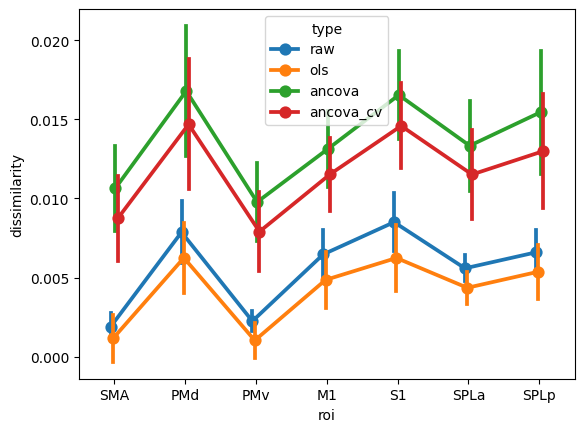

In [19]:
idx = np.triu_indices(5, k=1)
rows = []
for r, roi in enumerate(rois):
    G_raw = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    G_ols = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ols.glm{glm}.{H}.{roi}.npy'))
    G_ancova = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ancova.glm{glm}.{H}.{roi}.npy'))
    G_ancova_cv = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ancova_cv.glm{glm}.{H}.{roi}.npy'))

    for s, sn in enumerate(gl.sns):
        D_raw = pcm.G_to_dist(G_raw[s])
        D_ols = pcm.G_to_dist(G_ols[s])
        D_ancova = pcm.G_to_dist(G_ancova[s])
        D_ancova_cv = pcm.G_to_dist(G_ancova_cv[s])
        rows.append({'sn': sn, 'dissimilarity': D_raw.mean(), 'roi': roi, 'type': 'raw'})
        rows.append({'sn': sn, 'dissimilarity': D_ols.mean(), 'roi': roi, 'type': 'ols'})
        rows.append({'sn': sn, 'dissimilarity': D_ancova.mean(), 'roi': roi, 'type': 'ancova'})
        rows.append({'sn': sn, 'dissimilarity': D_ancova_cv.mean(), 'roi': roi, 'type': 'ancova_cv'})

df = pd.DataFrame(rows)
fig, ax = plt.subplots()

sb.pointplot(data=df, ax=ax, y='dissimilarity', x='roi', hue='type', errorbar='se', dodge=True)


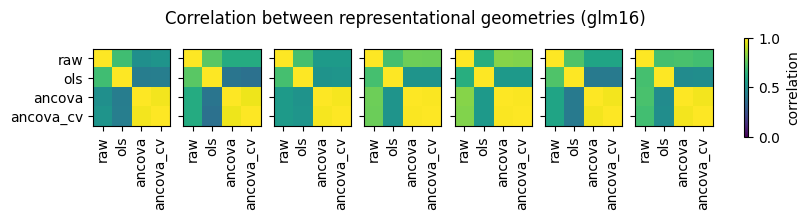

In [41]:
rows = []

idx = np.triu_indices(5, k=1)

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2), sharex=True, sharey=True, constrained_layout=True)

for r, roi in enumerate(rois):
    G_raw = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    G_ols = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ols.glm{glm}.{H}.{roi}.npy'))
    G_ancova = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ancova.glm{glm}.{H}.{roi}.npy'))
    G_ancova_cv = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ancova_cv.glm{glm}.{H}.{roi}.npy'))

    corr = np.zeros((len(gl.sns), 4, 4))
    for s, sn in enumerate(gl.sns):
        D_raw = pcm.G_to_dist(G_raw[s])[idx]
        D_ols = pcm.G_to_dist(G_ols[s])[idx]
        D_ancova = pcm.G_to_dist(G_ancova[s])[idx]
        D_ancova_cv = pcm.G_to_dist(G_ancova_cv[s])[idx]

        D = np.c_[D_raw, D_ols, D_ancova, D_ancova_cv]

        corr[s] = np.corrcoef(D.T)

    ax = axs[r]
    ax.imshow(corr.mean(axis=0), vmin=0, vmax=1, )
    ax.set_xticks(np.arange(4))
    ax.set_yticks(np.arange(4))
    ax.set_xticklabels(['raw', 'ols', 'ancova', 'ancova_cv'], rotation=90)
    ax.set_yticklabels(['raw', 'ols', 'ancova', 'ancova_cv'])

cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('correlation')
fig.suptitle(f'Correlation between representational geometries (glm{glm})')

plt.show()

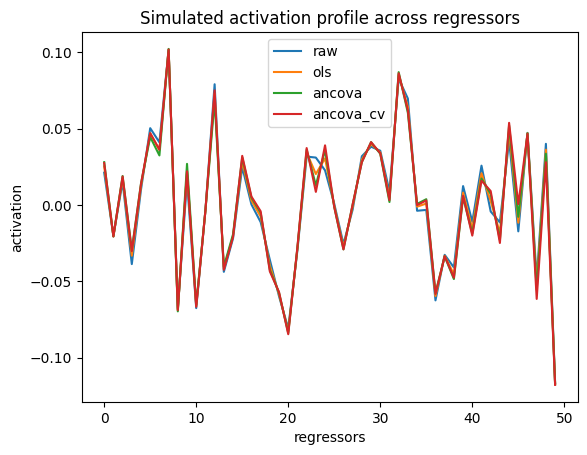

In [63]:
def ancova_regress_out_cv(B, F, Z, part_vec):
    n_f   = F.shape[1]
    B_res  = B.copy()

    for p in np.unique(part_vec):
        train = part_vec != p   # all partitions except p
        test  = part_vec == p   # partition p

        # Remove condition-mean structure from F in both sets
        F_train = F[train]
        F_test  = F[test]

        # Estimate W_F with OLS
        X_train = np.c_[F_train, Z[train]]
        W_train_ols = np.linalg.pinv(X_train) @ B[train]

        # Apply only F's contribution to the test partition
        B_res[test] = B[test] - F_test @ W_train_ols[:n_f]

    return B_res

iterations = 100
r_FZ = 0.05  # correlation between F and condition membership
n_cond, n_part, n_vox, n_channel = 5, 10, 500, 1
n_obs = n_cond * n_part  # 50 = one obs per condition per partition

D, D_simple, D_ols_cv, D_ancova, D_ancova_cv  = [np.zeros(iterations) for _ in range(5)]

for i in range(iterations):

    rng = np.random.default_rng(i)

    # Each partition contains one observation per condition (like fMRI runs)
    cond_vec      = np.tile(np.arange(n_cond), n_part)   # [0,1,2,3,4, 0,1,2,3,4, ...]
    part_vec      = np.repeat(np.arange(n_part), n_cond)  # [0,0,0,0,0, 1,1,1,1,1, ...]

    Z = pcm.indicator(cond_vec)    # condition indicators (n_obs x n_cond)

    # B: true condition effects + noise
    B = rng.standard_normal((n_obs, n_vox))

    # F: one continuous regressor with controlled correlation to Z
    F_correlated = Z @ rng.standard_normal((n_cond, n_channel))  # condition-structured
    F_uncorrelated  = rng.standard_normal((n_obs, n_channel))   # random
    F = np.sqrt(r_FZ) * F_correlated + np.sqrt(1 - r_FZ) * F_uncorrelated  #/ F_noise.std(0)
    F = F - F.mean(axis=0, keepdims=True)

    # Simple regression out: project B onto null space of F
    B_simple = B - F @ np.linalg.pinv(F) @ B

    # ANCOVA: joint model [F, Z], remove only F's contribution
    W = np.linalg.pinv(np.c_[F, Z]) @ B
    B_ancova = B - F @ W[:n_channel]

    # ANCOVA: joint model [F, Z], remove only F's contribution in a cross-validated manner
    B_ancova_cv = ancova_regress_out_cv(B, F, Z, part_vec,)

    G, _ = pcm.est_G_crossval(B, cond_vec, part_vec, X=pcm.indicator(part_vec))
    D[i] = pcm.G_to_dist(G).mean()

    G_simple, _ = pcm.est_G_crossval(B_simple, cond_vec, part_vec, X=pcm.indicator(part_vec))
    D_simple[i] = pcm.G_to_dist(G_simple).mean()

    G_ancova, _ = pcm.est_G_crossval(B_ancova, cond_vec, part_vec, X=pcm.indicator(part_vec))
    D_ancova[i] = pcm.G_to_dist(G_ancova).mean()

    G_ancova_cv, _ = pcm.est_G_crossval(B_ancova_cv, cond_vec, part_vec, X=pcm.indicator(part_vec))
    D_ancova_cv[i] = pcm.G_to_dist(G_ancova_cv).mean()

plt.plot(B.mean(axis=1), label='raw')
plt.plot(B_simple.mean(axis=1), label='ols')
plt.plot(B_ancova.mean(axis=1), label='ancova')
plt.plot(B_ancova_cv.mean(axis=1), label='ancova_cv')
plt.title('Simulated activation profile across regressors')
plt.ylabel('activation')
plt.xlabel('regressors')
plt.legend()
plt.show()

Text(0, 0.5, 'dissimilarity')

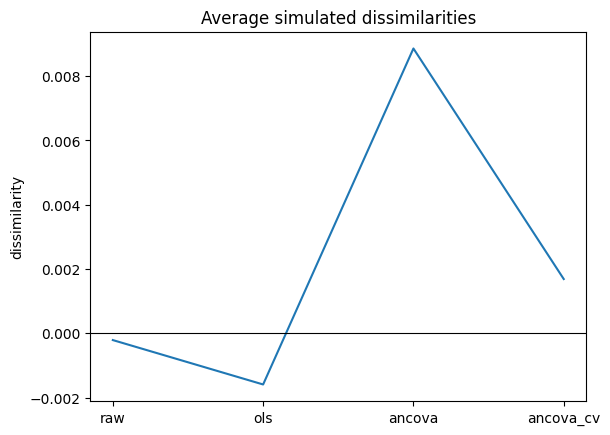

In [64]:
plt.plot(np.array([D.mean(), D_simple.mean(),  D_ancova.mean(), D_ancova_cv.mean(), ]))
ax = plt.gca()
ax.axhline(0, lw=.8, color='k')
ax.set_xticks(np.arange(4))
ax.set_xticklabels(['raw', 'ols', 'ancova', 'ancova_cv'])
ax.set_title('Average simulated dissimilarities')
ax.set_ylabel('dissimilarity')